## Main code

In [1]:
! # Make sure to enable the ipycanvas/ other widgets
!jupyter labextension enable widgetsnbextension

In [2]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import squidpy as sq

from popari.io import save_anndata, load_anndata

from popari.simulation_framework import MultiReplicateSyntheticDataset, SyntheticDataset, SimulationParameters

from pathlib import Path

import matplotlib.pyplot as plt
import random
import seaborn as sns

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [3]:
from importlib import reload
from popari import simulation_framework
reload(simulation_framework)
from popari.simulation_framework import MultiReplicateSyntheticDataset, SyntheticDataset, SimulationParameters

In [4]:
from popari.io import save_anndata, load_anndata
from popari.components import PopariDataset
from popari._dataset_utils import _plot_all_embeddings, _plot_in_situ, _multireplicate_heatmap, _compute_empirical_correlations

In [52]:
cell_type_definitions = {
    "Excitatory L1":         [0.5, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    "Excitatory L2":         [0.5, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    "Excitatory L3":         [0.5, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    "Excitatory L4":         [0.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    "Inhibitory L1":         [0, 0.5, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    "Inhibitory L2":         [0, 0.5, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    "Inhibitory L3":         [0, 0.5, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    "Inhibitory L4":         [0, 0.5, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    "Non-Neuron Ubiquitous": [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
}
progenitor_distributions = {
    "L1": {
        "Excitatory L1": 0.53,
        "Inhibitory L1": 0.2,
        "Inhibitory L2": 0.2,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L2": {
        "Excitatory L2": 0.53,
        "Inhibitory L2": 0.2,
        "Inhibitory L3": 0.2,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L3": {
        "Excitatory L3": 0.53,
        "Inhibitory L3": 0.2,
        "Inhibitory L4": 0.2,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L4": {
        "Excitatory L4": 0.53,
        "Inhibitory L3": 0.2,
        "Inhibitory L4": 0.2,
        "Non-Neuron Ubiquitous": 0.07,
    },
}

layer_distributions = {
    "L1": {
        "Excitatory L1": 0.2,
        "Excitatory L2": 0.2,
        "Inhibitory L1": 0.53,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L2": {
        "Excitatory L2": 0.2,
        "Excitatory L3": 0.2,
        "Inhibitory L2": 0.53,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L3": {
        "Excitatory L3": 0.2,
        "Excitatory L4": 0.2,
        "Inhibitory L3": 0.53,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L4": {
        "Excitatory L3": 0.2,
        "Excitatory L4": 0.2,
        "Inhibitory L4": 0.53,
        "Non-Neuron Ubiquitous": 0.07,
    },
}

metagene_variation_probabilities = [0, 0.1, 0, 0, 0.1, 0.1, 0.1, 0, 0.1, 0.1, 0.1]

shared_parameters = {
    'num_genes': 100,
    'annotation_mode': 'domain',
    'num_real_metagenes': 11,
    'num_noise_metagenes': 0,
    'sig_y_scale': 1.0,
    'sig_x_scale': 1.0,
    'real_metagene_parameter': 8.0,
    'noise_metagene_parameter': 4.0,
    'lambda_s': 1.,
    'width': 1,
    'height': 1,
    'grid_size': 15,
    'metagene_variation_probabilities': metagene_variation_probabilities,
    'cell_type_definitions': cell_type_definitions,
    'domain_key': 'domain',
}

progenitor_parameters = SimulationParameters(
    **shared_parameters,
    spatial_distributions=progenitor_distributions,
)

layer_parameters = SimulationParameters(
    **shared_parameters,
    spatial_distributions=layer_distributions,
)

num_copies = 1
duplicated_parameters = [
    {
        f"progenitor_{index}": progenitor_parameters,
        f"layer_{index}": layer_parameters,
    }
    for index in range(num_copies)
]
replicate_parameters = {replicate_name: parameters for replicate_parameters in duplicated_parameters for replicate_name, parameters in replicate_parameters.items()}

batch_effect = 0.5

In [53]:
multireplicate_dataset = MultiReplicateSyntheticDataset(replicate_parameters, SyntheticDataset, random_state=101, verbose=0, percent_batch_effect=batch_effect)

In [10]:
multireplicate_dataset.annotate_replicate_domain("layer_0")

Annotating replicate layer_0


Choose a domain to annotate (enter an integer):
0: L1
1: L2
2: L3
3: L4
 3


Output()

Canvas(height=600, image_data=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02X\x00\x00\x02X\x08\x06\x00\x00\…

In [11]:
layer_domains = multireplicate_dataset.datasets["layer_0"].domain_canvas.domains

multireplicate_dataset.datasets[f"progenitor_0"].domain_canvas.load_domains(layer_domains)
multireplicate_dataset.datasets[f"layer_0"].domain_canvas.load_domains(layer_domains) 

In [12]:
multireplicate_dataset.assign_domain_labels()

In [13]:
multireplicate_dataset.simulate_expression()

In [14]:
multireplicate_dataset.calculate_neighbors(coord_type="grid", n_neighs=4, delaunay=False)

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/utils.py:349: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


In [15]:
def sample_graph_iid(adjacency_list, indices_remaining, sample_size):                              
    valid_indices = []                                                                             
    excluded_indices = set()                                                                       
    effective_batch_size = min(sample_size, len(indices_remaining))                                
    candidate_indices = np.random.choice(list(indices_remaining),                                  
        size=effective_batch_size,                                                                 
        replace=False,                                                                             
    )                                                                                              
    for index in candidate_indices:                                                                
        if index not in excluded_indices:                                                                                                                                                                                                                                       
            valid_indices.append(index)                                                            
            excluded_indices |= set(adjacency_list[index])                                         
                                                                                                   
    return valid_indices   

def adjacency_matrix_to_list(adjacency_matrix):
    """
    """
    adjacency_matrix = adjacency_matrix.tocoo()                                

    num_cells, _ = adjacency_matrix.shape                                                      
    adjacency_list = [[] for _ in range(num_cells)]                                                                                                                                                                                                                         
    for x, y in zip(*adjacency_matrix.nonzero()):                                              
        adjacency_list[x].append(y)                                                            

    return adjacency_list   

In [16]:
(replicate_names, datasets) = zip(*multireplicate_dataset.datasets.items())

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/tools/_utils.py:40: UserWarning: You’re trying to run this on 100 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


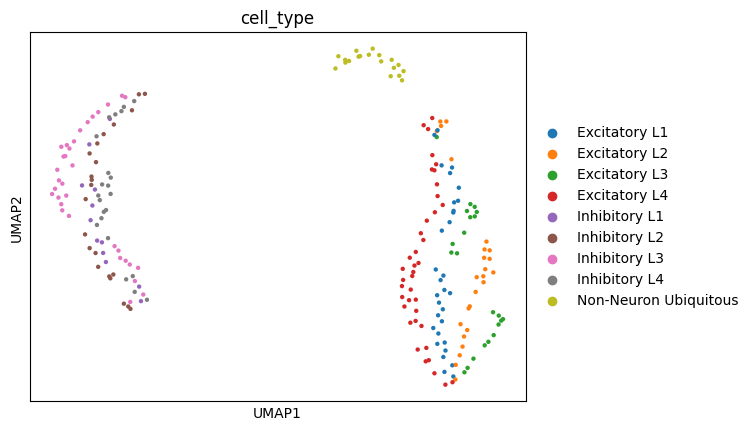

In [17]:
fig, ax = plt.subplots()
sc.pp.neighbors(datasets[0])
sc.tl.umap(datasets[0])
sc.pl.umap(datasets[0], color="cell_type", ax=ax, size=40)

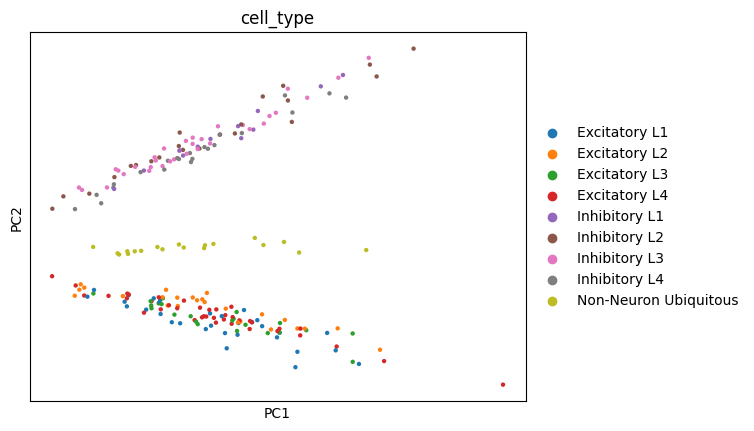

In [18]:
fig, ax = plt.subplots()
sc.tl.pca(datasets[0])
sc.pl.pca(datasets[0], color="cell_type", ax=ax, size=40)

In [19]:
from popari.util import concatenate

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/tools/_utils.py:40: UserWarning: You’re trying to run this on 100 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


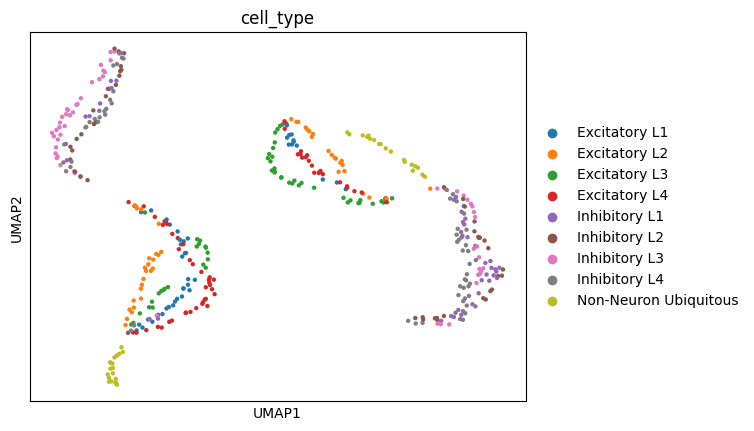

In [20]:
replicate_names, dataset_copies = zip(*multireplicate_dataset.datasets.items())
merged_dataset = concatenate(dataset_copies)                                                                                                                                        
fig, ax = plt.subplots()
sc.pp.neighbors(merged_dataset)
sc.tl.umap(merged_dataset)
sc.pl.umap(merged_dataset, color="cell_type", ax=ax, size=40)

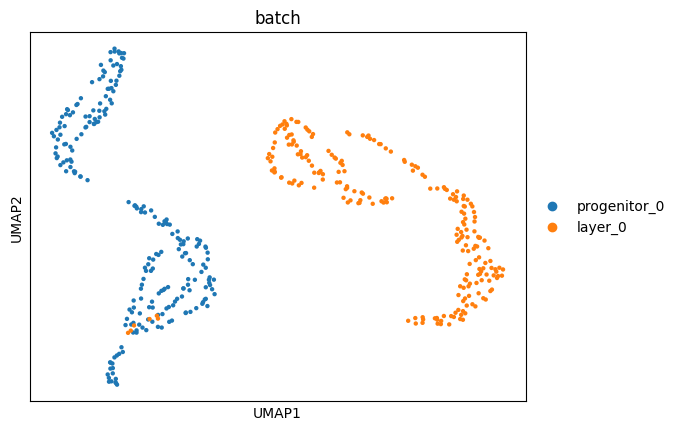

In [21]:
fig, ax = plt.subplots()
sc.pl.umap(merged_dataset, color="batch", ax=ax, size=40)

In [54]:
batch_effect_percent = batch_effect * 100
save_anndata(f"/home/raehashs/batch_effect_correction/popari/simulated_batch_data/processed_dataset_{batch_effect_percent}.h5ad", datasets)

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 450 × 100
    obs: 'domain', 'cell_type', 'cell_type_encoded', 'batch'
    uns: 'domain_names', 'simulation_parameters', 'cell_type_definitions', 'ground_truth_batch_effect', 'domain_landmarks', 'ground_truth_M', 'batch_effect', 'spatial_neighbors', 'pca', 'neighbors', 'umap', 'cell_type_colors', 'adjacency_matrix'
    obsm: 'spatial', 'ground_truth_X', 'adjacency_list', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'spatial_connectivities', 'spatial_distances', 'adjacency_matrix', 'distances', 'connectivities'

In [23]:
import torch
from popari.model import Popari
from popari import pl, tl
from popari.util import concatenate
import scanpy as sc
from matplotlib import pyplot as plt
from pathlib import Path

from popari.train import Trainer, BatchBlendTrainer, TrainParameters
from popari._dataset_utils import _plot_all_embeddings

In [55]:
lambda_Sigma_x_inv=1e-4
lambda_Sigma_bar=1e-4
torch_context={
    "dtype": torch.float64,
    "device": "cuda:0"
}
K = 11
seed = 42
nmf_preiterations = 10
num_iterations = 50
prior_x_mode = ["exponential shared fixed", "exponential shared fixed"]
dataset_path = Path("/home/raehashs/batch_effect_correction/popari/simulated_batch_data")



model = Popari(                                                              
    K=K,                                                                        
    dataset_path=dataset_path/f"processed_dataset_{batch_effect_percent}.h5ad",                                                                        
    lambda_Sigma_x_inv=lambda_Sigma_x_inv,
    spatial_affinity_mode="differential lookup",
    spatial_affinity_groups={
        "progenitor": ["progenitor_0"],
        "layer": ["layer_0"],
    },
    prior_x_modes = prior_x_mode, 
    initial_context=torch_context,                                              
    torch_context=torch_context,
    initialization_method="leiden",
    hierarchical_levels=1,
    verbose=1,                                                                  
    random_state=seed,
)                  

train_parameters = TrainParameters(
    nmf_iterations=nmf_preiterations,
    iterations=num_iterations,
    savepath=(dataset_path / f"trained_{num_iterations}_iterations.h5ad"),
)

trainer = Trainer(
    parameters=train_parameters,
    model=model,
    verbose=True,
)

trainer.train()   
#trainer.save_results()

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[2025/04/13 11:10:49]	 Initializing ParameterOptimizer
[2025/04/13 11:10:49]	 Initializing MetageneState
[2025/04/13 11:10:49]	 Initializing SpatialAffinityState
[2025/04/13 11:10:49]	 Initializing EmbeddingOptimizer
[2025/04/13 11:10:49]	 Initializing EmbeddingState
[2025/04/13 11:10:49]	 Initializing BatchEffectOptimizer
[2025/04/13 11:10:49]	 Initializing metagenes and hidden states using leiden method
Current number of clusters: 12
Resolution: 1.0
Current number of clusters: 7
Resolution: 0.31622776601683794
Current number of clusters: 9
Resolution: 0.5623413251903491
Current number of clusters: 10
Resolution: 0.7498942093324559
Current number of clusters: 10
Resolution: 0.8659643233600653
Current number of clusters: 10
Resolution: 0.930572040929699
Current number of clusters: 11
Resolution: 0.9646616199111993
[2025/04/13 11:10:49]	 Initializing Sigma_x_inv with empirical correlations


/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/raehashs/batch_effect_correction/popari/popari/initialization.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curre

  0%|          | 0/10 [00:00<?, ?it/s]

[2025/04/13 11:10:49]	 Updating metagenes


...

  0%|          | 0/1000 [00:00<?, ?it/s]

[2025/04/13 11:10:52]	 Updating metagenes


Updating M:   0%|          | 0/10000 [00:00<?, ?it/s]

Updating M:   0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


<Axes: title={'center': 'Batches (Popari)'}, xlabel='UMAP1', ylabel='UMAP2'>

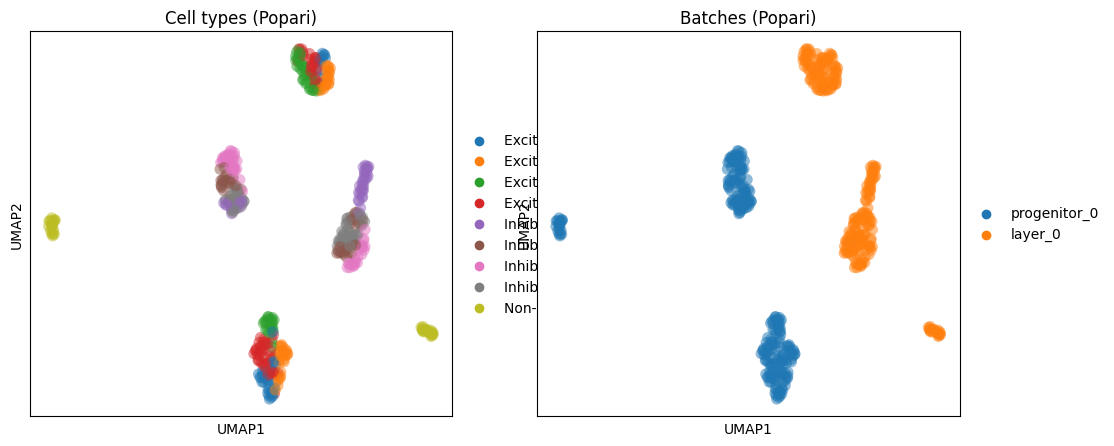

In [25]:
merged_dataset = concatenate(model.datasets)
merged_dataset.obsm["X_popari"] = merged_dataset.obsm["X"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sc.pp.neighbors(merged_dataset, use_rep="X_popari")
sc.tl.umap(merged_dataset)
sc.pl.umap(merged_dataset, color="cell_type", alpha=0.5, ax=ax1, show=False, title="Cell types (Popari)")
sc.pl.umap(merged_dataset, color="batch", alpha=0.5, ax=ax2, show=False, title="Batches (Popari)")

In [26]:
lambda_Sigma_x_inv=1e-4
lambda_Sigma_bar=1e-4
torch_context={
    "dtype": torch.float64,
    "device": "cuda:0"
}
K = 11
seed = 42
nmf_preiterations = 10
num_iterations = 50
prior_x_mode = ["exponential shared fixed", "exponential shared fixed"]
dataset_path = Path("/home/raehashs/batch_effect_correction/popari/simulated_batch_data")

model = Popari(                                                              
    K=K,                                                                        
    dataset_path=dataset_path/f"processed_dataset_{batch_effect_percent}.h5ad",                                                                        
    lambda_Sigma_x_inv=lambda_Sigma_x_inv,
    spatial_affinity_mode="differential lookup",
    spatial_affinity_groups={
        "progenitor": ["progenitor_0"],
        "layer": ["layer_0"],
    },
    prior_x_modes = prior_x_mode, 
    initial_context=torch_context,                                              
    torch_context=torch_context,
    initialization_method="leiden",
    hierarchical_levels=1,
    verbose=1,                                                                  
    random_state=seed,
    batch_effect_correction=True,
)      

train_parameters = TrainParameters(
    nmf_iterations=nmf_preiterations,
    iterations=num_iterations,
    savepath=(f"/home/raehashs/batch_effect_correction/popari/simulated_batch_data/trained_{num_iterations}_iterations_batch.h5ad"),
)

trainer = BatchBlendTrainer(
    parameters=train_parameters,
    model=model,
    verbose=True,
)

trainer.train()  
#trainer.save_results()

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[2025/04/13 10:47:14]	 Initializing ParameterOptimizer
[2025/04/13 10:47:14]	 Initializing MetageneState
[2025/04/13 10:47:14]	 Initializing SpatialAffinityState
[2025/04/13 10:47:14]	 Initializing EmbeddingOptimizer
[2025/04/13 10:47:14]	 Initializing EmbeddingState
[2025/04/13 10:47:14]	 Initializing BatchEffectOptimizer
[2025/04/13 10:47:14]	 Initializing BatchEffectState
[2025/04/13 10:47:14]	 Initializing metagenes and hidden states using leiden method
Current number of clusters: 12
Resolution: 1.0
Current number of clusters: 7
Resolution: 0.31622776601683794
Current number of clusters: 9
Resolution: 0.5623413251903491
Current number of clusters: 10
Resolution: 0.7498942093324559
Current number of clusters: 10
Resolution: 0.8659643233600653
Current number of clusters: 10
Resolution: 0.930572040929699
Current number of clusters: 11
Resolution: 0.9646616199111993


/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/raehashs/batch_effect_correction/popari/popari/initialization.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curre

[2025/04/13 10:47:15]	 Initializing Sigma_x_inv with empirical correlations


  0%|          | 0/10 [00:00<?, ?it/s]

...

Updating weight w/ neighbors:   0%|          | 0/1000 [00:00<?, ?it/s]

Updating weight w/ neighbors:   0%|          | 0/1000 [00:00<?, ?it/s]

[2025/04/13 10:56:35]	 Updating batch effect


Updating batch effect with Nesterov's AG:   0%|          | 0/1000 [00:00<?, ?it/s]

Updating batch effect with Nesterov's AG:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


<Axes: title={'center': 'Batches (Batch Blend)'}, xlabel='UMAP1', ylabel='UMAP2'>

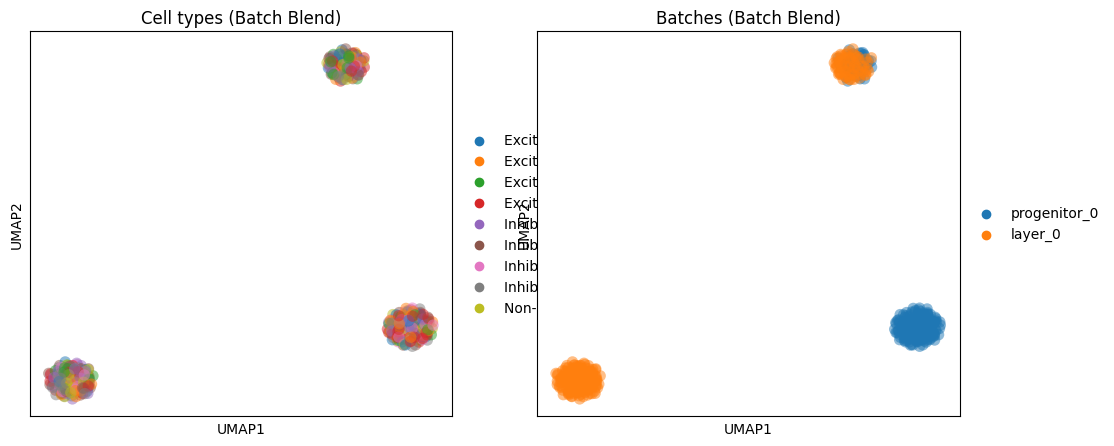

In [27]:
merged_dataset = concatenate(model.datasets)
merged_dataset.obsm["X_batch_blend"] = merged_dataset.obsm["X"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sc.pp.neighbors(merged_dataset, use_rep="X_batch_blend")
sc.tl.umap(merged_dataset)
sc.pl.umap(merged_dataset, color="cell_type", alpha=0.5, ax=ax1, show=False, title="Cell types (Batch Blend)")
sc.pl.umap(merged_dataset, color="batch", alpha=0.5, ax=ax2, show=False, title="Batches (Batch Blend)")

[[1.e-15 1.e-15 1.e-05 ... 1.e-15 1.e-15 1.e-15]
 [1.e-15 1.e-15 1.e-15 ... 1.e-15 1.e-15 1.e-15]
 [1.e-15 1.e-15 1.e-05 ... 1.e-15 1.e-15 1.e-15]
 ...
 [1.e-15 1.e-15 1.e-05 ... 1.e-15 1.e-15 1.e-15]
 [1.e-15 1.e-15 1.e-15 ... 1.e-15 1.e-15 1.e-15]
 [1.e-15 1.e-15 1.e-05 ... 1.e-15 1.e-15 1.e-15]] [5.97240429e+01 4.37264076e+02 1.56822682e+02 1.00000000e-05
 4.65611347e+01 1.00000000e-05 1.14725910e+02 1.41915649e+02
 1.00000000e-05 8.53570230e+02 6.65449877e+02] [[-5.97240429e+01 -4.37264076e+02 -1.56822672e+02 ... -1.00000000e-05
  -8.53570230e+02 -6.65449877e+02]
 [-5.97240429e+01 -4.37264076e+02 -1.56822682e+02 ... -1.00000000e-05
  -8.53570230e+02 -6.65449877e+02]
 [-5.97240429e+01 -4.37264076e+02 -1.56822672e+02 ... -1.00000000e-05
  -8.53570230e+02 -6.65449877e+02]
 ...
 [-5.97240429e+01 -4.37264076e+02 -1.56822672e+02 ... -1.00000000e-05
  -8.53570230e+02 -6.65449877e+02]
 [-5.97240429e+01 -4.37264076e+02 -1.56822682e+02 ... -1.00000000e-05
  -8.53570230e+02 -6.65449877e+02]
 

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


<Axes: title={'center': 'Batches (Batch Blend)'}, xlabel='UMAP1', ylabel='UMAP2'>

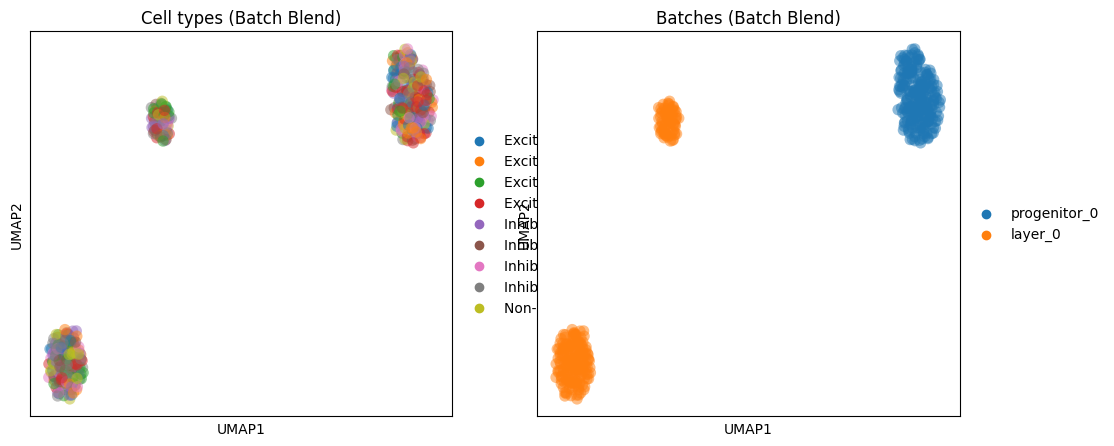

In [51]:
for dataset in model.datasets:
    batch_effect_key = list(dataset.uns['batch_effect'].keys())[0]
    batch_effect = dataset.uns['batch_effect'][batch_effect_key]
    original_data = dataset.obsm['X']
    batch_corrected_data = original_data - batch_effect #remove batch effect
    dataset.obsm['X_batch_blend'] = batch_corrected_data
    print(original_data, batch_effect, batch_corrected_data)
merged_dataset = concatenate(model.datasets)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sc.pp.neighbors(merged_dataset, use_rep="X_batch_blend")
sc.tl.umap(merged_dataset)
sc.pl.umap(merged_dataset, color="cell_type", alpha=0.5, ax=ax1, show=False, title="Cell types (Batch Blend)")
sc.pl.umap(merged_dataset, color="batch", alpha=0.5, ax=ax2, show=False, title="Batches (Batch Blend)")